In [ ]:
import numpy as np
import matplotlib.pyplot as plt


Ny = 50                  # number of grid points
height = 5.0

# discretize the space, these are our observation points
y = np.linspace(0, height, Ny)
dy = y[1] - y[0] # spacing between these points

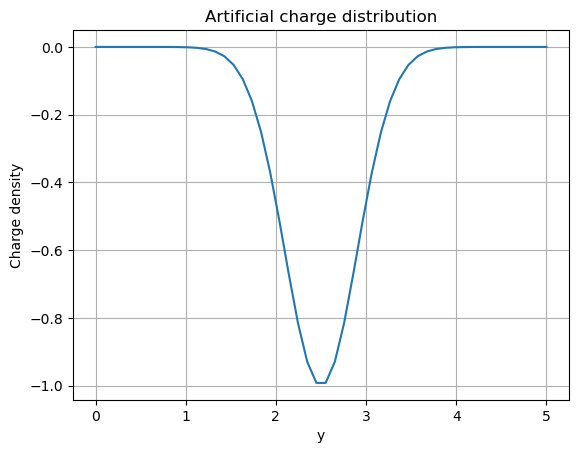

[-3.29371411e-09 -1.57032087e-08 -7.01501009e-08 -2.93633494e-07
 -1.15164939e-06 -4.23226027e-06 -1.45734323e-05 -4.70206604e-05
 -1.42152007e-04 -4.02674998e-04 -1.06879331e-03 -2.65809310e-03
 -6.19418316e-03 -1.35249383e-02 -2.76709418e-02 -5.30456754e-02
 -9.52825610e-02 -1.60366723e-01 -2.52902129e-01 -3.73704314e-01
 -5.17417522e-01 -6.71261206e-01 -8.15979714e-01 -9.29404071e-01
 -9.91898365e-01 -9.91898365e-01 -9.29404071e-01 -8.15979714e-01
 -6.71261206e-01 -5.17417522e-01 -3.73704314e-01 -2.52902129e-01
 -1.60366723e-01 -9.52825610e-02 -5.30456754e-02 -2.76709418e-02
 -1.35249383e-02 -6.19418316e-03 -2.65809310e-03 -1.06879331e-03
 -4.02674998e-04 -1.42152007e-04 -4.70206604e-05 -1.45734323e-05
 -4.23226027e-06 -1.15164939e-06 -2.93633494e-07 -7.01501009e-08
 -1.57032087e-08 -3.29371411e-09]


In [27]:
epsilon = 1
sigma = 0.4

rho = -np.exp(-(y-height/2)**2/(2*sigma**2))

plt.plot(y, rho)
plt.xlabel("y")
plt.ylabel("Charge density")
plt.title("Artificial charge distribution")
plt.grid(True)
plt.show()

print(rho)

In [24]:
V = np.zeros(Ny) #array of potential for each grid point created above
V[0] = 0
V[-1] = 0
# we have no idea what the potential is and where so we start with an array of zeros

In [25]:
for iteration in range(5000): #this is not in time, just run the thing for as long as nothing changes significantly

    for i in range(1, Ny-1): #we skip 0 and N as only inner points get values the boundary points are already defined above

        V[i] = 0.5 * (
            V[i-1]
            + V[i+1]
            + rho[i] * dy**2 / epsilon
        )

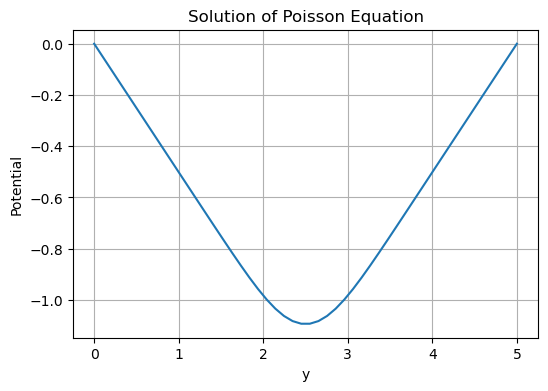

In [26]:
plt.figure(figsize=(6,4))
plt.plot(y, V)

plt.xlabel("y")
plt.ylabel("Potential")

plt.title("Solution of Poisson Equation")

plt.grid(True)

plt.show()

In [20]:
Ey = -np.gradient(V, dy)

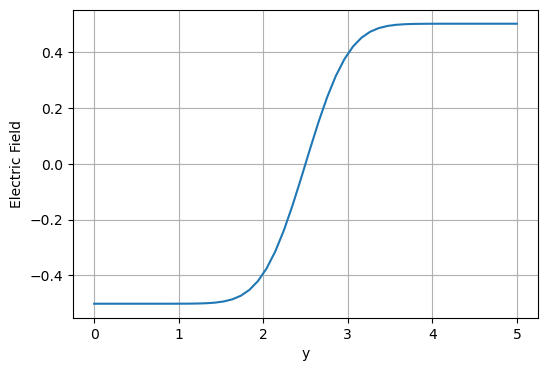

In [21]:
plt.figure(figsize=(6,4))
plt.plot(y, Ey)

plt.xlabel("y")
plt.ylabel("Electric Field")

plt.grid(True)

plt.show()